In [25]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the provided JSON file
file_path = 'DE_L_results_T_10_delta_5_scen_21_trial_1_inv_2_cap._1_cap.inc._5.json'
with open(file_path, 'r') as file:
    data = json.load(file)

In [12]:
# Extract unique producers from the provided data
unique_producers = set()

# Collect unique producers from commitment amounts
for vaccine, producers in combined_data["Q_commitment_amounts"].items():
    for producer in producers:
        unique_producers.add(producer)

# Collect unique producers from production amounts
for vaccine, producers in combined_data["X_production_amounts"].items():
    for producer in producers:
        unique_producers.add(producer)

unique_producers_list = list(unique_producers)
unique_producers_list


['GSK',
 'AJ_Vaccines',
 'Biological_E',
 'Panacea_Biotec',
 'LG_Chem',
 'Sanofi',
 'BB_NCIPD',
 'Serum_Institute',
 'Bharat_Biotech',
 'China_National',
 'Haffkine_Bio',
 'PT_Bio',
 'Bilthoven',
 'Merck_Sharp',
 'Pfizer']

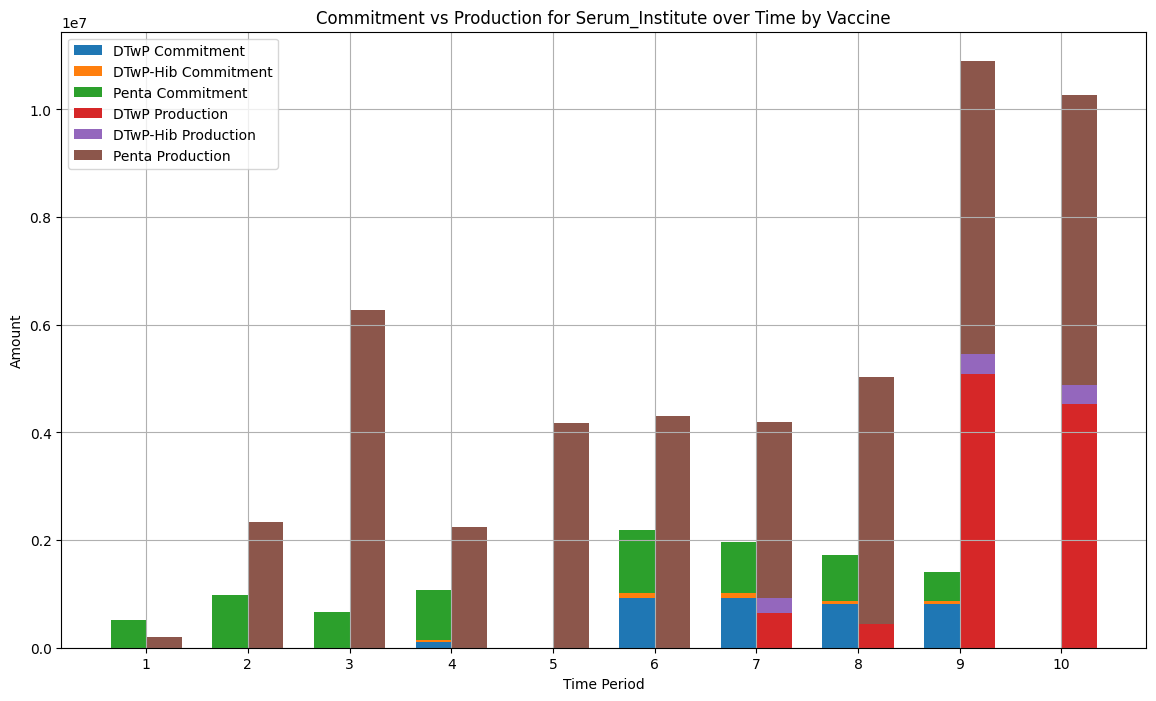

In [16]:
# Provided combined data dictionary
combined_data = {
    "F_tender_schedule": data.get("F", {}),
    "Y_manufacturers_producing_period": data.get("Y", {}),
    "W_manufacturers_participate_tender": data.get("W", {}),
    "L_capacity_extension_decision": data.get("L", {}),
    "Q_commitment_amounts": data.get("Q", {}),
    "X_production_amounts": data.get("X", {}),
    "I_inventory_level": data.get("I", {}),
    "Vc_vaccinated_children": data.get("Vc", {}),
    "S_unvaccinated_children": data.get("S", {})
}

# Vaccines to filter
vaccines_to_filter = ["DTwP", "DTwP-Hib", "Penta"]

# Initialize dictionaries to store commitment and production amounts by vaccine
commitment_results = {}
production_results = {}

# Filter data to only look at Serum_Institute for the specified vaccines in commitments
for vaccine, producers in combined_data["Q_commitment_amounts"].items():
    if vaccine in vaccines_to_filter and "Serum_Institute" in producers:
        for time_period, commitments in producers["Serum_Institute"].items():
            if time_period not in commitment_results:
                commitment_results[time_period] = {}
            if vaccine not in commitment_results[time_period]:
                commitment_results[time_period][vaccine] = 0
            # Sum up the commitment amounts for the current time period and vaccine
            commitment_results[time_period][vaccine] += sum(commitments.values())

# Filter data to only look at Serum_Institute for the specified vaccines in productions
for vaccine, producers in combined_data["X_production_amounts"].items():
    if vaccine in vaccines_to_filter and "Serum_Institute" in producers:
        for time_period, production in producers["Serum_Institute"].items():
            if time_period not in production_results:
                production_results[time_period] = {}
            if vaccine not in production_results[time_period]:
                production_results[time_period][vaccine] = 0
            # Sum the values if production is a nested dictionary
            if isinstance(production, dict):
                production_results[time_period][vaccine] += sum(production.values())
            else:
                production_results[time_period][vaccine] += production

# Prepare data for visualization
time_periods = sorted(set(commitment_results.keys()).union(production_results.keys()), key=int)
vaccines = sorted(vaccines_to_filter)

commitment_data = {vaccine: [commitment_results.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}
production_data = {vaccine: [production_results.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}

# Convert to DataFrame for easier manipulation
df_commitment = pd.DataFrame(commitment_data, index=time_periods)
df_production = pd.DataFrame(production_data, index=time_periods)

# Plotting the data
bar_width = 0.35
index = np.arange(len(time_periods))

fig, ax = plt.subplots(figsize=(14, 8))

# Stacked bar for commitments
bottom_commitment = np.zeros(len(time_periods))
for vaccine in vaccines:
    ax.bar(index, df_commitment[vaccine], bar_width, label=f'{vaccine} Commitment', bottom=bottom_commitment)
    bottom_commitment += df_commitment[vaccine]

# Stacked bar for productions
bottom_production = np.zeros(len(time_periods))
for vaccine in vaccines:
    ax.bar(index + bar_width, df_production[vaccine], bar_width, label=f'{vaccine} Production', bottom=bottom_production)
    bottom_production += df_production[vaccine]

ax.set_xlabel('Time Period')
ax.set_ylabel('Amount')
ax.set_title('Commitment vs Production for Serum_Institute over Time by Vaccine')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(time_periods)
ax.legend()

plt.grid(True)
plt.show()


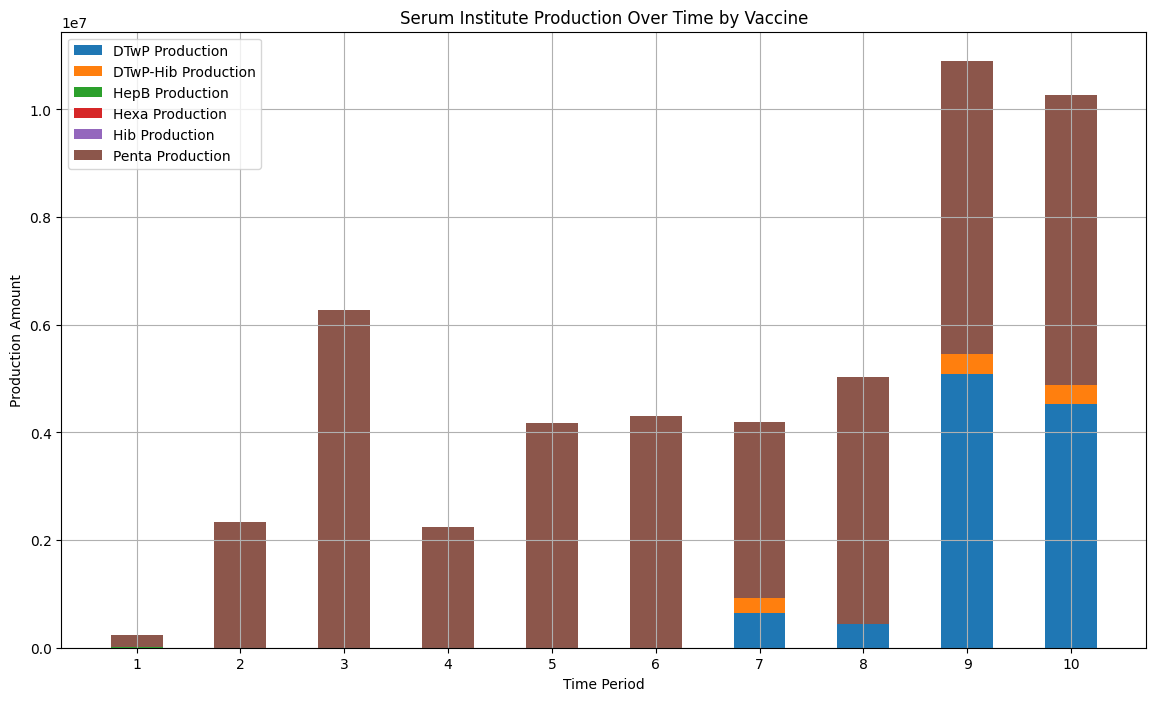

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Provided combined data dictionary
combined_data = {
    "F_tender_schedule": data.get("F", {}),
    "Y_manufacturers_producing_period": data.get("Y", {}),
    "W_manufacturers_participate_tender": data.get("W", {}),
    "L_capacity_extension_decision": data.get("L", {}),
    "Q_commitment_amounts": data.get("Q", {}),
    "X_production_amounts": data.get("X", {}),
    "I_inventory_level": data.get("I", {}),
    "Vc_vaccinated_children": data.get("Vc", {}),
    "S_unvaccinated_children": data.get("S", {})
}

# Vaccines to filter
vaccines_to_filter = ["DTwP", "DTwP-Hib", "Penta", "Hexa", "HepB", "Hib"]

# Initialize dictionary to store production amounts by vaccine and time period for Serum_Institute
serum_institute_production = {}

# Collect data for Serum_Institute and the specified vaccines in productions
for vaccine, producers in combined_data["X_production_amounts"].items():
    if vaccine in vaccines_to_filter and "Serum_Institute" in producers:
        for time_period, production in producers["Serum_Institute"].items():
            if time_period not in serum_institute_production:
                serum_institute_production[time_period] = {}
            if vaccine not in serum_institute_production[time_period]:
                serum_institute_production[time_period][vaccine] = 0
            # Sum the values if production is a nested dictionary
            if isinstance(production, dict):
                serum_institute_production[time_period][vaccine] += sum(production.values())
            else:
                serum_institute_production[time_period][vaccine] += production

# Prepare data for visualization
time_periods = sorted(serum_institute_production.keys(), key=int)
vaccines = sorted(vaccines_to_filter)

production_data = {vaccine: [serum_institute_production.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}

# Convert to DataFrame for easier manipulation
df_production = pd.DataFrame(production_data, index=time_periods)

# Plotting the data
bar_width = 0.5
index = np.arange(len(time_periods))

fig, ax = plt.subplots(figsize=(14, 8))

# Stacked bar for productions
bottom_production = np.zeros(len(time_periods))
for vaccine in vaccines:
    ax.bar(index, df_production[vaccine], bar_width, label=f'{vaccine} Production', bottom=bottom_production)
    bottom_production += df_production[vaccine]

ax.set_xlabel('Time Period')
ax.set_ylabel('Production Amount')
ax.set_title('Serum Institute Production Over Time by Vaccine')
ax.set_xticks(index)
ax.set_xticklabels(time_periods)
ax.legend()

plt.grid(True)
plt.show()



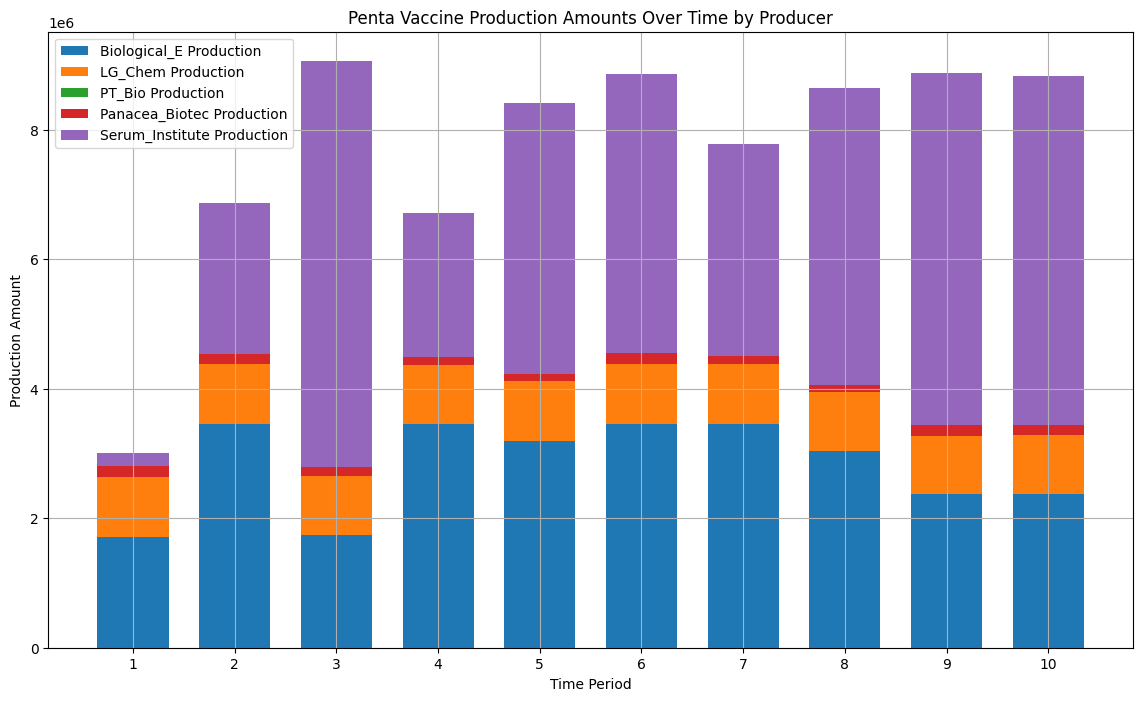

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Initialize dictionary to store production amounts by producer and time period for Penta vaccine
penta_production = {}

# Collect data for all producers for Penta vaccine in productions
for vaccine, producers in combined_data["X_production_amounts"].items():
    if vaccine == "Penta":
        for producer, time_periods in producers.items():
            for time_period, production in time_periods.items():
                if producer not in penta_production:
                    penta_production[producer] = {}
                if time_period not in penta_production[producer]:
                    penta_production[producer][time_period] = 0
                # Sum the values if production is a nested dictionary
                if isinstance(production, dict):
                    penta_production[producer][time_period] += sum(production.values())
                else:
                    penta_production[producer][time_period] += production

# Prepare data for visualization
time_periods = sorted(set(tp for producer_data in penta_production.values() for tp in producer_data), key=int)
producers = sorted(penta_production.keys())

production_data = {producer: [penta_production.get(producer, {}).get(tp, 0) for tp in time_periods] for producer in producers}

# Convert to DataFrame for easier manipulation
df_production = pd.DataFrame(production_data, index=time_periods)

# Plotting the data
bar_width = 0.7
index = np.arange(len(time_periods))

fig, ax = plt.subplots(figsize=(14, 8))

# Stacked bar for productions
bottom_production = np.zeros(len(time_periods))
for producer in producers:
    ax.bar(index, df_production[producer], bar_width, label=f'{producer} Production', bottom=bottom_production)
    bottom_production += df_production[producer]

ax.set_xlabel('Time Period')
ax.set_ylabel('Production Amount')
ax.set_title('Penta Vaccine Production Amounts Over Time by Producer')
ax.set_xticks(index)
ax.set_xticklabels(time_periods)
ax.legend()

plt.grid(True)
plt.show()



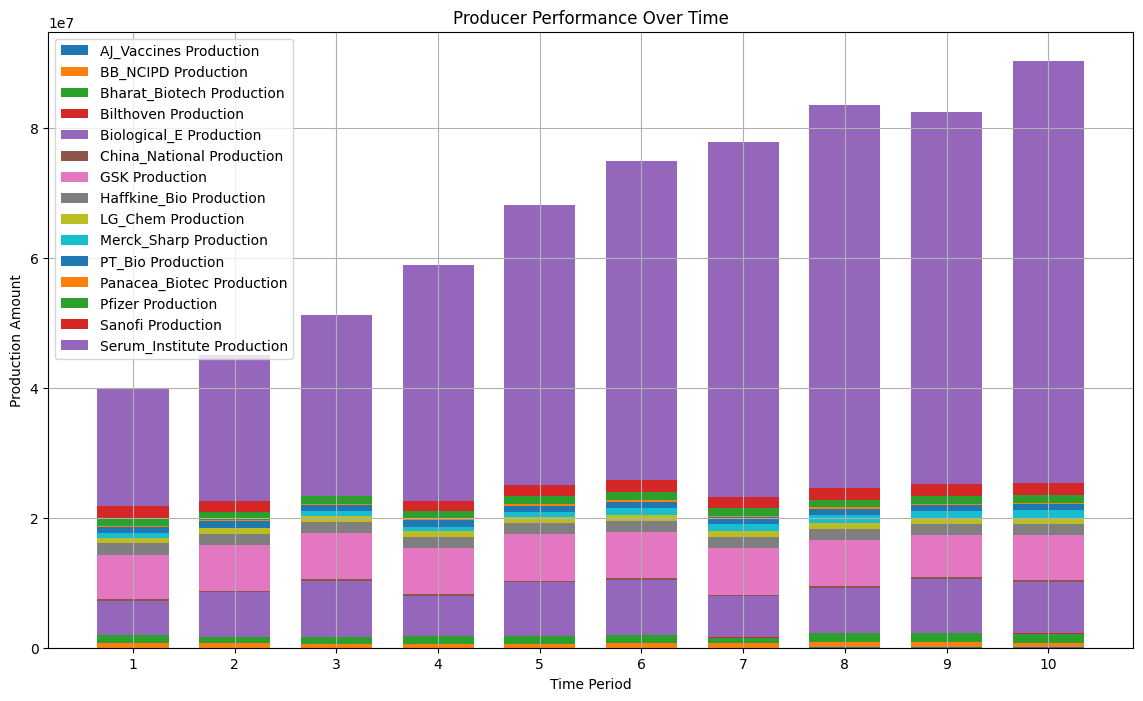

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Provided combined data dictionary
combined_data = {
    "F_tender_schedule": data.get("F", {}),
    "Y_manufacturers_producing_period": data.get("Y", {}),
    "W_manufacturers_participate_tender": data.get("W", {}),
    "L_capacity_extension_decision": data.get("L", {}),
    "Q_commitment_amounts": data.get("Q", {}),
    "X_production_amounts": data.get("X", {}),
    "I_inventory_level": data.get("I", {}),
    "Vc_vaccinated_children": data.get("Vc", {}),
    "S_unvaccinated_children": data.get("S", {})
}

# Initialize a dictionary to store production amounts by producer and year
production_results = {}

# Collect data for all producers and vaccines in productions
for vaccine, producers in combined_data["X_production_amounts"].items():
    for producer, time_periods in producers.items():
        for time_period, production in time_periods.items():
            if producer not in production_results:
                production_results[producer] = {}
            if time_period not in production_results[producer]:
                production_results[producer][time_period] = 0
            # Sum the values if production is a nested dictionary
            if isinstance(production, dict):
                production_results[producer][time_period] += sum(production.values())
            else:
                production_results[producer][time_period] += production

# Prepare data for visualization
time_periods = sorted(set(tp for producer_data in production_results.values() for tp in producer_data), key=int)
producers = sorted(production_results.keys())

production_data = {producer: [production_results.get(producer, {}).get(tp, 0) for tp in time_periods] for producer in producers}

# Convert to DataFrame for easier manipulation
df_production = pd.DataFrame(production_data, index=time_periods)

# Plotting the data
bar_width = 0.7
index = np.arange(len(time_periods))

fig, ax = plt.subplots(figsize=(14, 8))

# Stacked bar for productions
bottom_production = np.zeros(len(time_periods))
for producer in producers:
    ax.bar(index, df_production[producer], bar_width, label=f'{producer} Production', bottom=bottom_production)
    bottom_production += df_production[producer]

ax.set_xlabel('Time Period')
ax.set_ylabel('Production Amount')
ax.set_title('Producer Performance Over Time')
ax.set_xticks(index)
ax.set_xticklabels(time_periods)
ax.legend()

plt.grid(True)
plt.show()



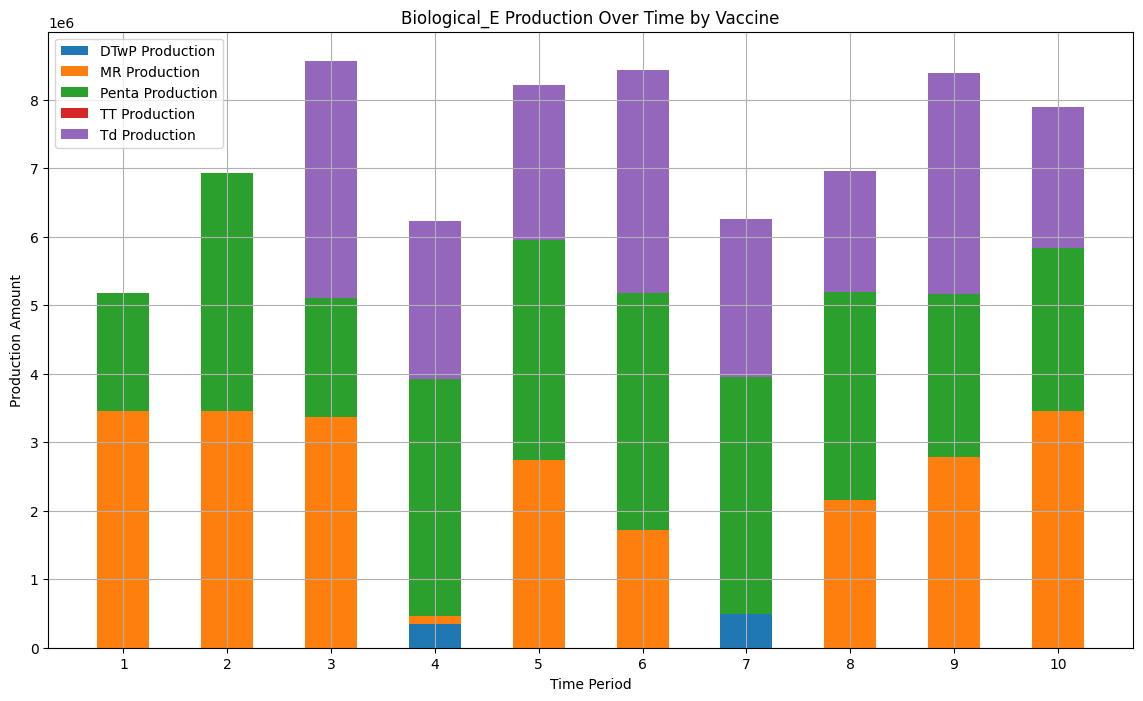

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Initialize dictionary to store production amounts by vaccine and time period for Biological_E
biological_e_production = {}

# Collect data for Biological_E for all vaccines in productions
for vaccine, producers in combined_data["X_production_amounts"].items():
    if "Biological_E" in producers:
        for time_period, production in producers["Biological_E"].items():
            if time_period not in biological_e_production:
                biological_e_production[time_period] = {}
            if vaccine not in biological_e_production[time_period]:
                biological_e_production[time_period][vaccine] = 0
            # Sum the values if production is a nested dictionary
            if isinstance(production, dict):
                biological_e_production[time_period][vaccine] += sum(production.values())
            else:
                biological_e_production[time_period][vaccine] += production

# Prepare data for visualization
time_periods = sorted(biological_e_production.keys(), key=int)
vaccines = sorted(set(vaccine for tp_data in biological_e_production.values() for vaccine in tp_data))

production_data = {vaccine: [biological_e_production.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}

# Convert to DataFrame for easier manipulation
df_production = pd.DataFrame(production_data, index=time_periods)

# Plotting the data
bar_width = 0.5
index = np.arange(len(time_periods))

fig, ax = plt.subplots(figsize=(14, 8))

# Stacked bar for productions
bottom_production = np.zeros(len(time_periods))
for vaccine in vaccines:
    ax.bar(index, df_production[vaccine], bar_width, label=f'{vaccine} Production', bottom=bottom_production)
    bottom_production += df_production[vaccine]

ax.set_xlabel('Time Period')
ax.set_ylabel('Production Amount')
ax.set_title('Biological_E Production Over Time by Vaccine')
ax.set_xticks(index)
ax.set_xticklabels(time_periods)
ax.legend()

plt.grid(True)
plt.show()

